# Phase 2: Exploratory Data Analysis (EDA)

## Group Roles and Responsibilities

- **Venkata Sai Rahul Unnam**  
  Designed research objectives and system architecture.

- **Gudhibandi Vedhagna Reddy**  
  Prepared background, motivation, and project documentation.

- **Prajapati Viral Kumar Chetankumar**  
  Dataset identification, data loading, preprocessing, and EDA implementation.

- **Puchala Arvind Reddy**  
  Literature review and academic references.

In [ ]:
# Install required libraries
!pip install datasets pandas matplotlib seaborn

In [ ]:
from datasets import load_dataset
import pandas as pd

# Load SWE-bench Lite dataset
dataset = load_dataset("princeton-nlp/SWE-bench_Lite")

# Convert to pandas DataFrame
df = pd.DataFrame(dataset["test"])

# Display first few rows
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/dev-00000-of-00001.parquet:   0%|          | 0.00/120k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.12M [00:00<?, ?B/s]

Generating dev split:   0%|          | 0/23 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/300 [00:00<?, ? examples/s]

,repo,instance_id,base_commit,patch,test_patch,problem_statement,hints_text,created_at,version,FAIL_TO_PASS,PASS_TO_PASS,environment_setup_commit
0,astropy/astropy,astropy__astropy-12907,d16bfe05a744909de4b27f5875fe0d4ed41ce607,diff --git a/astropy/modeling/separable.py b/a...,diff --git a/astropy/modeling/tests/test_separ...,Modeling's `separability_matrix` does not comp...,,2022-03-03T15:14:54Z,4.3,"[""astropy/modeling/tests/test_separable.py::te...","[""astropy/modeling/tests/test_separable.py::te...",298ccb478e6bf092953bca67a3d29dc6c35f6752
1,astropy/astropy,astropy__astropy-14182,a5917978be39d13cd90b517e1de4e7a539ffaa48,diff --git a/astropy/io/ascii/rst.py b/astropy...,diff --git a/astropy/io/ascii/tests/test_rst.p...,Please support header rows in RestructuredText...,,2022-12-16T11:13:37Z,5.1,"[""astropy/io/ascii/tests/test_rst.py::test_rst...","[""astropy/io/ascii/tests/test_rst.py::test_rea...",5f74eacbcc7fff707a44d8eb58adaa514cb7dcb5
2,astropy/astropy,astropy__astropy-14365,7269fa3e33e8d02485a647da91a5a2a60a06af61,diff --git a/astropy/io/ascii/qdp.py b/astropy...,diff --git a/astropy/io/ascii/tests/test_qdp.p...,ascii.qdp Table format assumes QDP commands ar...,Welcome to Astropy 👋 and thank you for your fi...,2023-02-06T19:20:34Z,5.1,"[""astropy/io/ascii/tests/test_qdp.py::test_rou...","[""astropy/io/ascii/tests/test_qdp.py::test_get...",5f74eacbcc7fff707a44d8eb58adaa514cb7dcb5
3,astropy/astropy,astropy__astropy-14995,b16c7d12ccbc7b2d20364b89fb44285bcbfede54,diff --git a/astropy/nddata/mixins/ndarithmeti...,diff --git a/astropy/nddata/mixins/tests/test_...,"In v5.3, NDDataRef mask propagation fails when...",Welcome to Astropy 👋 and thank you for your fi...,2023-06-27T19:48:18Z,5.2,"[""astropy/nddata/mixins/tests/test_ndarithmeti...","[""astropy/nddata/mixins/tests/test_ndarithmeti...",362f6df12abf9bd769d4915fabf955c993ea22cf
4,astropy/astropy,astropy__astropy-6938,c76af9ed6bb89bfba45b9f5bc1e635188278e2fa,diff --git a/astropy/io/fits/fitsrec.py b/astr...,diff --git a/astropy/io/fits/tests/test_checks...,Possible bug in io.fits related to D exponents...,It is tested with `astropy/io/fits/tests/test_...,2017-12-07T00:01:14Z,1.3,"[""astropy/io/fits/tests/test_checksum.py::Test...","[""astropy/io/fits/tests/test_checksum.py::Test...",848c8fa21332abd66b44efe3cb48b72377fb32cc


## Dataset Overview

The SWE-bench Lite dataset contains real-world GitHub issues and corresponding patches.
Each record represents a software bug-fix task with repository metadata, issue text,
and patch information.

In [ ]:
# Shape of dataset
df.shape

(300, 12)

In [ ]:
# Column names
df.columns

Index(['repo', 'instance_id', 'base_commit', 'patch', 'test_patch',
       'problem_statement', 'hints_text', 'created_at', 'version',
       'FAIL_TO_PASS', 'PASS_TO_PASS', 'environment_setup_commit'],
      dtype='object')

In [ ]:
# Check missing values
df.isnull().sum()

,0
repo,0
instance_id,0
base_commit,0
patch,0
test_patch,0
problem_statement,0
hints_text,0
created_at,0
version,0
FAIL_TO_PASS,0


## Descriptive Statistics

In [ ]:
# Length of problem statements
df["problem_length"] = df["problem_statement"].apply(len)

df["problem_length"].describe()

,problem_length
count,300.000000
mean,1661.176667
std,2447.983340
min,230.000000
25%,626.000000
50%,1043.500000
75%,1868.500000
max,24770.000000


In [ ]:
# Mean and median problem length
mean_length = df["problem_length"].mean()
median_length = df["problem_length"].median()

mean_length, median_length

(np.float64(1661.1766666666667), 1043.5)

In [ ]:
# Correlation example
df[["problem_length"]].corr()

,problem_length
problem_length,1.0


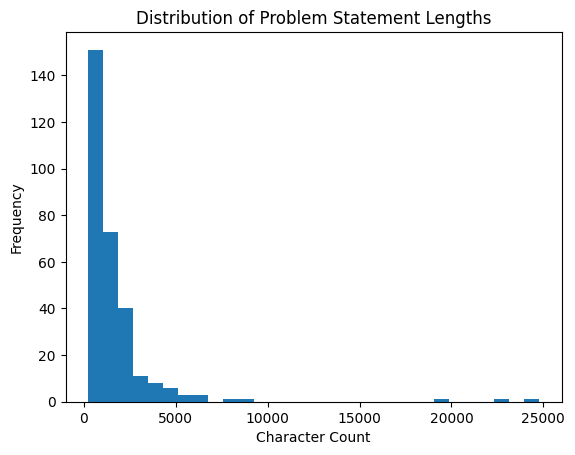

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.hist(df["problem_length"], bins=30)
plt.title("Distribution of Problem Statement Lengths")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.show()

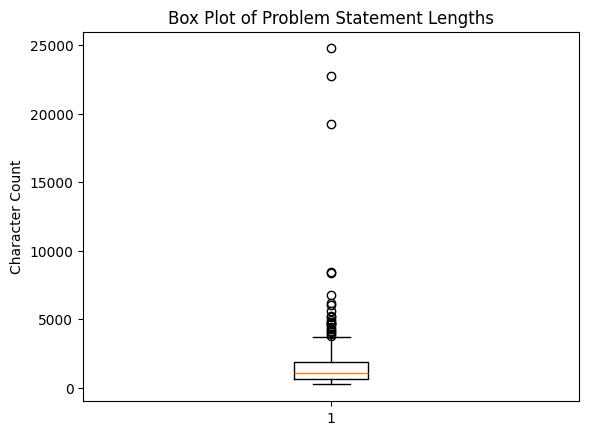

In [ ]:
plt.figure()
plt.boxplot(df["problem_length"])
plt.title("Box Plot of Problem Statement Lengths")
plt.ylabel("Character Count")
plt.show()

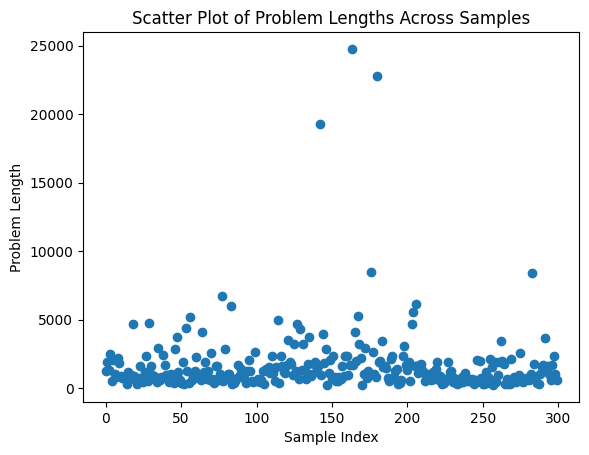

In [ ]:
plt.figure()
plt.scatter(range(len(df)), df["problem_length"])
plt.title("Scatter Plot of Problem Lengths Across Samples")
plt.xlabel("Sample Index")
plt.ylabel("Problem Length")
plt.show()

## Key Observations

- Most problem statements fall within a moderate character length range.
- Several outliers indicate very complex real-world issues.
- The dataset shows high variability, reinforcing the challenge of repository-level bug fixing.
- These characteristics justify the need for an autonomous agent with retrieval and verification loops.